# TCGA-BRCA Advanced Modeling v2 — Larger Cohort, Leakage-Fixed Fusion, Attention-MIL Pathology



# PART A — Data Pipeline (resumable: skips anything already in your Drive)

## A0. Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import requests
import json
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import f_classif
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

SAVE_DIR = "/content/drive/MyDrive/tcga_brca_project"
os.makedirs(SAVE_DIR, exist_ok=True)


def download_with_retry(uuid, out_path, max_retries=3, timeout=30):
    for attempt in range(max_retries):
        try:
            resp = requests.get(f"https://api.gdc.cancer.gov/data/{uuid}", stream=True, timeout=timeout)
            resp.raise_for_status()
            with open(out_path, "wb") as f:
                for chunk in resp.iter_content(chunk_size=8192):
                    f.write(chunk)
            return True
        except (requests.exceptions.ConnectionError, requests.exceptions.Timeout, requests.exceptions.HTTPError):
            time.sleep(2)
    return False


def download_batch(file_ids, file_names, save_dir, log_every=50):
    '''Downloads only what isn't already on Drive. Anything with a matching filename
    already present is skipped, so re-running this after adding more patients only
    fetches the new ones.'''
    os.makedirs(save_dir, exist_ok=True)
    failed, skipped = [], 0
    for i, (uuid, fname) in enumerate(zip(file_ids, file_names)):
        out_path = os.path.join(save_dir, fname)
        if os.path.exists(out_path):
            skipped += 1
            continue
        if not download_with_retry(uuid, out_path):
            failed.append((uuid, fname))
        if i % log_every == 0:
            print(f"  Progress: {i}/{len(file_ids)} (skipped so far: {skipped})")
    print(f"Done. {skipped} already present and skipped, {len(failed)} failed after retries.")
    return failed


def simplify_stage(s):
    if pd.isna(s):
        return None
    s = s.upper()
    if "IV" in s: return "Stage IV"
    if "III" in s: return "Stage III"
    if "II" in s: return "Stage II"
    if "STAGE I" in s or s in ("STAGE IA", "STAGE IB"): return "Stage I"
    return "Other/Unknown"


def load_one_sample(path, submitter_id):
    df = pd.read_csv(path, sep="\t", skiprows=1)
    df = df[df["gene_name"].notna()]
    s = df.groupby("gene_name")["tpm_unstranded"].sum()
    s.name = submitter_id
    return s

print("Setup ready.")

Setup ready.


## A1. Clinical Data

In [ ]:
DRIVE_ROOT = "/content/drive/MyDrive/tcga_brca_project"

url = "https://api.gdc.cancer.gov/cases"
filters = {"op": "in", "content": {"field": "project.project_id", "value": ["TCGA-BRCA"]}}
params = {
    "filters": json.dumps(filters),
    "fields": "case_id,submitter_id,demographic.gender,demographic.vital_status,diagnoses.age_at_diagnosis",
    "format": "TSV", "size": "1200"
}

clinical_path = os.path.join(DRIVE_ROOT, "tcga_brca_clinical.tsv")
if os.path.exists(clinical_path):
    print("Clinical data already on Drive, skipping download.")
else:
    r = requests.get(url, params=params)
    r.raise_for_status()
    with open(clinical_path, "wb") as f:
        f.write(r.content)

clinical_df = pd.read_csv(clinical_path, sep="\t")
clinical_df = clinical_df.rename(columns={"demographic.vital_status": "vital_status"})
age_cols = [c for c in clinical_df.columns if c.startswith("diagnoses.") and c.endswith(".age_at_diagnosis")]
if age_cols:
    clinical_df["age_at_diagnosis"] = clinical_df[age_cols].bfill(axis=1).iloc[:, 0]
    clinical_df = clinical_df.drop(columns=age_cols)

print(f"Clinical records: {clinical_df.shape}")
print(clinical_df["vital_status"].value_counts())

Clinical data already on Drive, skipping download.
Clinical records: (1098, 5)
vital_status
Alive    945
Dead     152
Name: count, dtype: int64


## A2. Gene Expression Files

In [ ]:
files_url = "https://api.gdc.cancer.gov/files"
filters = {
    "op": "and",
    "content": [
        {"op": "in", "content": {"field": "cases.project.project_id", "value": ["TCGA-BRCA"]}},
        {"op": "in", "content": {"field": "data_type", "value": ["Gene Expression Quantification"]}},
        {"op": "in", "content": {"field": "analysis.workflow_type", "value": ["STAR - Counts"]}}
    ]
}
all_hits = []
size, from_ = 500, 0
while True:
    params = {"filters": json.dumps(filters), "fields": "file_id,file_name,cases.submitter_id",
              "format": "JSON", "size": size, "from": from_}
    r = requests.get(files_url, params=params)
    hits = r.json()["data"]["hits"]
    if not hits: break
    all_hits.extend(hits)
    from_ += size
    if len(hits) < size: break

files_df = pd.json_normalize(all_hits)
files_df["submitter_id"] = files_df["cases"].apply(lambda x: x[0]["submitter_id"])
print(f"Gene expression files: {len(files_df)}")

Gene expression files: 1231


## A3. Download + Build Expression Matrix

In [ ]:
GENE_DIR = os.path.join(SAVE_DIR, "gene_expr")
os.makedirs(GENE_DIR, exist_ok=True)

# download_batch already skips any file that exists on Drive -- safe to re-run.
download_batch(files_df["file_id"].tolist(), files_df["file_name"].tolist(), GENE_DIR)

Done. 1231 already present and skipped, 0 failed after retries.


[]

In [ ]:
expr_cache_path = os.path.join(SAVE_DIR, "expr_matrix_cache.parquet")

if os.path.exists(expr_cache_path):
    print("Expression matrix cache found on Drive, loading instead of re-parsing raw files.")
    expr_matrix = pd.read_parquet(expr_cache_path)
else:
    expr_series_list = []
    for fname, pid in zip(files_df["file_name"], files_df["submitter_id"]):
        path = os.path.join(GENE_DIR, fname)
        try:
            expr_series_list.append(load_one_sample(path, pid))
        except Exception as e:
            print(f"Skipped {pid}: {e}")

    expr_matrix = pd.concat(expr_series_list, axis=1).T
    expr_matrix.index.name = "submitter_id"
    expr_matrix = expr_matrix[~expr_matrix.index.duplicated(keep="first")]
    expr_matrix.to_parquet(expr_cache_path)

gene_cols = expr_matrix.columns.tolist()
print(f"Expression matrix: {expr_matrix.shape}, duplicate cols: {expr_matrix.columns.duplicated().sum()}")

Expression matrix cache found on Drive, loading instead of re-parsing raw files.
Expression matrix: (1095, 59427), duplicate cols: 0


## A4. Merge Clinical + PAM50 + Stage (cBioPortal)

In [ ]:
# ---- Class configuration ----

MERGE_STAGE_III_IV = True

TARGET_COLUMN = "PAM50_subtype"

# ---- Merge expression + clinical ----
merged = expr_matrix.reset_index().merge(clinical_df, on="submitter_id", how="inner")

# ---- Pull PAM50 (SUBTYPE) and stage from cBioPortal ----
study_id = "brca_tcga_pan_can_atlas_2018"
cbio_base = "https://www.cbioportal.org/api"

r = requests.get(f"{cbio_base}/studies/{study_id}/patients", params={"projection": "SUMMARY"})
r.raise_for_status()
patients = [p["patientId"] for p in r.json()]

r = requests.post(f"{cbio_base}/studies/{study_id}/clinical-data/fetch",
                  params={"clinicalDataType": "PATIENT"},
                  json={"attributeIds": ["SUBTYPE"], "ids": patients})
r.raise_for_status()
subtype_df = pd.DataFrame(r.json())[["patientId", "value"]]
subtype_df.columns = ["submitter_id", "PAM50_subtype"]
subtype_df["PAM50_subtype"] = (
    subtype_df["PAM50_subtype"]
    .astype(str)
    .str.replace("BRCA_", "", regex=False)
    .str.strip()
)

r = requests.post(f"{cbio_base}/studies/{study_id}/clinical-data/fetch",
                  params={"clinicalDataType": "PATIENT"},
                  json={"attributeIds": ["AJCC_PATHOLOGIC_TUMOR_STAGE"], "ids": patients})
r.raise_for_status()
stage_df = pd.DataFrame(r.json())[["patientId", "value"]]
stage_df.columns = ["submitter_id", "ajcc_pathologic_stage"]

# ---- Attach labels to merged ----
merged = merged.merge(subtype_df, on="submitter_id", how="left")
merged = merged.merge(stage_df, on="submitter_id", how="left")

# ---- Build stage_group (unchanged logic) ----
merged["stage_group_raw"] = merged["ajcc_pathologic_stage"].apply(simplify_stage)
if MERGE_STAGE_III_IV:
    merged["stage_group"] = merged["stage_group_raw"].replace(
        {"Stage IV": "Stage III/IV", "Stage III": "Stage III/IV"}
    )
else:
    merged["stage_group"] = merged["stage_group_raw"]

# ---- Normalize PAM50 a bit ----
# Common cBioPortal values: "LumA", "LumB", "Basal", "Her2", "Normal", "Normal-like", "" (empty)
merged["PAM50_subtype"] = merged["PAM50_subtype"].replace(
    {"": np.nan, "nan": np.nan, "None": np.nan}
)
# Collapse "Normal-like" -> "Normal" if present
merged["PAM50_subtype"] = merged["PAM50_subtype"].replace({"Normal-like": "Normal"})

# ---- Sanity checks ----
print(f"Merged shape: {merged.shape}")

print("\n--- stage_group distribution ---")
print(merged["stage_group"].value_counts(dropna=False))

print("\n--- PAM50_subtype distribution ---")
print(merged["PAM50_subtype"].value_counts(dropna=False))

# ---- Drop rows with a missing TARGET_COLUMN ----
before = len(merged)
merged = merged.dropna(subset=[TARGET_COLUMN]).copy()
after = len(merged)
print(f"\nDropped {before - after} rows missing {TARGET_COLUMN}  ({before} -> {after})")

print(f"\nFinal target = '{TARGET_COLUMN}':")
print(merged[TARGET_COLUMN].value_counts())

# ---- Warn if any class has too few samples ----
counts = merged[TARGET_COLUMN].value_counts()
too_small = counts[counts < 30]
if len(too_small) > 0:
    print("\n[warning] Classes with fewer than 30 samples -- CV folds will be unstable:")
    print(too_small)

Merged shape: (1095, 59436)

--- stage_group distribution ---
stage_group
Stage II         614
Stage III/IV     268
Stage I          180
None              19
Other/Unknown     14
Name: count, dtype: int64

--- PAM50_subtype distribution ---
PAM50_subtype
LumA      499
LumB      197
Basal     171
NaN       114
Her2       78
Normal     36
Name: count, dtype: int64

Dropped 114 rows missing PAM50_subtype  (1095 -> 981)

Final target = 'PAM50_subtype':
PAM50_subtype
LumA      499
LumB      197
Basal     171
Her2       78
Normal     36
Name: count, dtype: int64


## A5. Pathology WSI Cohort — Larger, Resumable, Storage-Aware

In [ ]:
# ---- Cohort size / storage configuration ----
TARGET_PER_CLASS = {
    "LumA": 216,
    "LumB": 85,
    "Basal": 60,
    "Her2": 30,
    "Normal": 14,
}

MAX_PATCHES_PER_SLIDE = 300
DELETE_RAW_WSI_AFTER_PROCESSING = True

WSI_DIR = os.path.join(SAVE_DIR, "wsi_slides")
PATCH_CACHE_DIR = os.path.join(SAVE_DIR, "patch_cache")
FEATURE_CACHE_DIR = os.path.join(SAVE_DIR, "wsi_feature_cache")
for d in (WSI_DIR, PATCH_CACHE_DIR, FEATURE_CACHE_DIR):
    os.makedirs(d, exist_ok=True)

wsi_files_url = "https://api.gdc.cancer.gov/files"
wsi_filters = {
    "op": "and",
    "content": [
        {"op": "in", "content": {"field": "cases.project.project_id", "value": ["TCGA-BRCA"]}},
        {"op": "in", "content": {"field": "data_type", "value": ["Slide Image"]}},
        {"op": "in", "content": {"field": "experimental_strategy", "value": ["Diagnostic Slide"]}},
    ],
}
all_hits_wsi = []
size, from_ = 200, 0
while True:
    params = {
        "filters": json.dumps(wsi_filters),
        "fields": "file_id,file_name,file_size,cases.submitter_id",
        "format": "JSON",
        "size": size,
        "from": from_,
    }
    r = requests.get(wsi_files_url, params=params)
    r.raise_for_status()
    hits = r.json()["data"]["hits"]
    if not hits:
        break
    all_hits_wsi.extend(hits)
    from_ += size
    if len(hits) < size:
        break

wsi_df = pd.json_normalize(all_hits_wsi)
wsi_df["submitter_id"] = wsi_df["cases"].apply(lambda x: x[0]["submitter_id"])
wsi_df["file_size_gb"] = wsi_df["file_size"] / 1e9

wsi_df = wsi_df.sort_values("file_size_gb", ascending=False)
wsi_df = wsi_df.drop_duplicates("submitter_id", keep="first")

target_lookup = dict(zip(merged["submitter_id"], merged[TARGET_COLUMN]))
wsi_df["target"] = wsi_df["submitter_id"].map(target_lookup)

pilot_wsi = wsi_df.dropna(subset=["target"]).copy()

already_cached = {
    f.split(".")[0] for f in os.listdir(FEATURE_CACHE_DIR) if f.endswith(".npy")
}
print(f"Patients already cached: {len(already_cached)}")


def sample_target(class_name, group):
    target = TARGET_PER_CLASS.get(class_name, len(group))
    cached_in_group = group[group["submitter_id"].isin(already_cached)]
    remaining = max(target - len(cached_in_group), 0)
    pool = group[~group["submitter_id"].isin(already_cached)]
    extra = pool.sample(n=min(len(pool), remaining), random_state=42) if remaining > 0 else pool.iloc[0:0]
    return pd.concat([cached_in_group, extra])


parts = []
for class_name, group in pilot_wsi.groupby("target"):
    parts.append(sample_target(class_name, group))
pilot_wsi = pd.concat(parts, ignore_index=True).copy()
pilot_wsi["target"] = pilot_wsi["submitter_id"].map(target_lookup)

n_new = (~pilot_wsi["submitter_id"].isin(already_cached)).sum()
print("\n--- Selected cohort ---")
print(pilot_wsi["target"].value_counts())
print(f"Total patients selected: {len(pilot_wsi)} ({n_new} not yet cached -- should be 0)")

Patients already cached: 447

--- Selected cohort ---
target
LumA      216
LumB       85
Basal      60
Her2       30
Normal     14
Name: count, dtype: int64
Total patients selected: 405 (0 not yet cached -- should be 0)


In [ ]:
to_download = pilot_wsi[~pilot_wsi["submitter_id"].isin(already_cached)]
download_batch(to_download["file_id"].tolist(), to_download["file_name"].tolist(), WSI_DIR, log_every=5)

Done. 0 already present and skipped, 0 failed after retries.


[]

In [ ]:
!pip install openslide-python -q
!apt-get install openslide-tools -q -y

Reading package lists...
Building dependency tree...
Reading state information...
The following additional packages will be installed:
  libopenslide0
Suggested packages:
  libtiff-tools
The following NEW packages will be installed:
  libopenslide0 openslide-tools
0 upgraded, 2 newly installed, 0 to remove and 52 not upgraded.
Need to get 101 kB of archives.
After this operation, 297 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu noble/universe amd64 libopenslide0 amd64 3.4.1+dfsg-7build2 [86.9 kB]
Get:2 http://archive.ubuntu.com/ubuntu noble/universe amd64 openslide-tools amd64 3.4.1+dfsg-7build2 [14.0 kB]
Fetched 101 kB in 1s (170 kB/s)
Selecting previously unselected package libopenslide0.
(Reading database ... 126952 files and directories currently installed.)
Preparing to unpack .../libopenslide0_3.4.1+dfsg-7build2_amd64.deb ...
Unpacking libopenslide0 (3.4.1+dfsg-7build2) ...
Selecting previously unselected package openslide-tools.
Preparing to u

In [ ]:
import openslide

def get_tissue_patches(slide_path, level=1, patch_size=256, tissue_thresh=0.8, max_patches=None):
    slide = openslide.OpenSlide(slide_path)
    level = min(level, slide.level_count - 1)
    w, h = slide.level_dimensions[level]
    patches, coords = [], []
    for y in range(0, h - patch_size, patch_size):
        for x in range(0, w - patch_size, patch_size):
            patch = slide.read_region((x * (2**level), y * (2**level)), level, (patch_size, patch_size))
            patch = patch.convert("RGB")
            arr = np.array(patch)
            white_ratio = np.mean(np.all(arr > 220, axis=-1))
            if white_ratio < tissue_thresh:
                patches.append(arr)
                coords.append((x, y))
            if max_patches and len(patches) >= max_patches:
                return patches, coords
    return patches, coords

print("Tiling function ready.")

Tiling function ready.


In [ ]:
import torch
import torchvision.models as models
import torchvision.transforms as T

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device, "-- use a GPU runtime for Part C (CNN fine-tuning) if this says 'cpu'.")

resnet_frozen = models.resnet50(weights="IMAGENET1K_V2")
resnet_frozen.fc = torch.nn.Identity()
resnet_frozen = resnet_frozen.to(device).eval()

eval_transform = T.Compose([
    T.ToPILImage(), T.Resize((224, 224)), T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def extract_features(patches, batch_size=32, model=None):
    model = model or resnet_frozen
    feats = []
    with torch.no_grad():
        for i in range(0, len(patches), batch_size):
            batch = torch.stack([eval_transform(p) for p in patches[i:i+batch_size]]).to(device)
            out = model(batch)
            feats.append(out.cpu().numpy())
    return np.concatenate(feats, axis=0)

print("extract_features ready.")

Device: cuda -- use a GPU runtime for Part C (CNN fine-tuning) if this says 'cpu'.
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 93.3MB/s]


extract_features ready.


In [ ]:
patient_wsi_features = {}
patient_n_patches = {}

for i, (fname, pid) in enumerate(zip(pilot_wsi["file_name"], pilot_wsi["submitter_id"])):
    feat_path = os.path.join(FEATURE_CACHE_DIR, f"{pid}.npy")
    patch_path = os.path.join(PATCH_CACHE_DIR, f"{pid}.npz")

    if os.path.exists(feat_path) and os.path.exists(patch_path):
        patient_wsi_features[pid] = np.load(feat_path)
        patient_n_patches[pid] = np.load(patch_path)["patches"].shape[0]
        print(f"[{i+1}/{len(pilot_wsi)}] {pid}: cached, skipping")
        continue

    slide_path = os.path.join(WSI_DIR, fname)
    if not os.path.exists(slide_path):
        print(f"  Slide missing for {pid} (not downloaded and not cached), skipping")
        continue

    try:
        patches, coords = get_tissue_patches(slide_path, max_patches=MAX_PATCHES_PER_SLIDE)
        if len(patches) == 0:
            print(f"  No tissue patches for {pid}, skipping")
            continue
        feats = extract_features(patches)
        mean_feat = feats.mean(axis=0)

        np.save(feat_path, mean_feat)
        np.savez_compressed(patch_path, patches=np.stack(patches).astype(np.uint8))

        patient_wsi_features[pid] = mean_feat
        patient_n_patches[pid] = len(patches)
        print(f"[{i+1}/{len(pilot_wsi)}] {pid}: {len(patches)} patches, cached")

        if DELETE_RAW_WSI_AFTER_PROCESSING:
            os.remove(slide_path)
    except Exception as e:
        print(f"  FAILED for {pid}: {e}")

print(f"\nPatients with pathology features available (this run + previously cached): {len(patient_wsi_features)}")

[1/405] TCGA-EW-A1PH: cached, skipping
[2/405] TCGA-D8-A1JK: cached, skipping
[3/405] TCGA-AR-A0U4: cached, skipping
[4/405] TCGA-D8-A27F: cached, skipping
[5/405] TCGA-E2-A14X: cached, skipping
[6/405] TCGA-E2-A150: cached, skipping
[7/405] TCGA-S3-AA15: cached, skipping
[8/405] TCGA-A1-A0SK: cached, skipping
[9/405] TCGA-BH-A0B9: cached, skipping
[10/405] TCGA-B6-A1KF: cached, skipping
[11/405] TCGA-A2-A0YE: cached, skipping
[12/405] TCGA-BH-A0BW: cached, skipping
[13/405] TCGA-S3-AA0Z: cached, skipping
[14/405] TCGA-A2-A0SX: cached, skipping
[15/405] TCGA-E2-A573: cached, skipping
[16/405] TCGA-B6-A0RT: cached, skipping
[17/405] TCGA-EW-A1P4: cached, skipping
[18/405] TCGA-D8-A1XQ: cached, skipping
[19/405] TCGA-OL-A6VO: cached, skipping
[20/405] TCGA-BH-A0AV: cached, skipping
[21/405] TCGA-AN-A0AT: cached, skipping
[22/405] TCGA-E9-A244: cached, skipping
[23/405] TCGA-E2-A1LH: cached, skipping
[24/405] TCGA-BH-A0BL: cached, skipping
[25/405] TCGA-D8-A1XK: cached, skipping
[26/405] 

In [ ]:
wsi_feat_df = pd.DataFrame.from_dict(patient_wsi_features, orient="index")
wsi_feat_df.columns = [f"wsi_feat_{i}" for i in range(wsi_feat_df.shape[1])]
wsi_feat_df.index.name = "submitter_id"
wsi_feat_df = wsi_feat_df.reset_index()

merged_with_wsi = merged.merge(wsi_feat_df, on="submitter_id", how="inner")
model_df = merged_with_wsi[~merged_with_wsi["stage_group"].isin([None, "Other/Unknown"])].copy()
print(f"Fused modeling set: {model_df.shape}")
print(model_df["stage_group"].value_counts())

Fused modeling set: (405, 61484)
stage_group
Stage II        152
Stage I         146
Stage III/IV    107
Name: count, dtype: int64


# PART B — Attention Fusion (leakage-fixed, cross-validated)

In [ ]:
!pip install torch --quiet
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(42)

wsi_feat_cols = [c for c in model_df.columns if c.startswith("wsi_feat_")]
y_stage = LabelEncoder().fit_transform(model_df[TARGET_COLUMN].values)
n_classes = len(np.unique(y_stage))
class_names = sorted(model_df[TARGET_COLUMN].unique(), key=lambda s: LabelEncoder().fit(model_df[TARGET_COLUMN]).transform([s])[0])

print(f"Patients: {len(model_df)}, pathology feature dim: {len(wsi_feat_cols)}, classes: {n_classes}")
print(model_df[TARGET_COLUMN].value_counts())

Patients: 405, pathology feature dim: 2048, classes: 5
PAM50_subtype
LumA      216
LumB       85
Basal      60
Her2       30
Normal     14
Name: count, dtype: int64


In [ ]:
class AttentionFusionModel(nn.Module):
    '''Separate per-modality encoders, combined via a single-head cross-attention layer,
    followed by a classification head (intermediate fusion).'''
    def __init__(self, gene_dim, path_dim, hidden_dim=64, n_classes=4, dropout=0.4):
        super().__init__()
        self.gene_encoder = nn.Sequential(
            nn.Linear(gene_dim, 256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, hidden_dim), nn.ReLU()
        )
        self.path_encoder = nn.Sequential(
            nn.Linear(path_dim, 256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, hidden_dim), nn.ReLU()
        )
        self.query_proj = nn.Linear(hidden_dim, hidden_dim)
        self.key_proj = nn.Linear(hidden_dim, hidden_dim)
        self.value_proj = nn.Linear(hidden_dim, hidden_dim)
        self.scale = hidden_dim ** 0.5

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, n_classes)
        )

    def forward(self, x_gene, x_path):
        g = self.gene_encoder(x_gene)
        p = self.path_encoder(x_path)

        q = self.query_proj(g).unsqueeze(1)
        kv = torch.stack([self.key_proj(g), self.key_proj(p)], dim=1)
        v = torch.stack([self.value_proj(g), self.value_proj(p)], dim=1)

        attn_scores = torch.bmm(q, kv.transpose(1, 2)) / self.scale
        attn_weights = F.softmax(attn_scores, dim=-1)
        attended = torch.bmm(attn_weights, v).squeeze(1)

        combined = torch.cat([attended, p], dim=1)
        out = self.classifier(combined)
        return out, attn_weights.squeeze(1)

print("AttentionFusionModel defined.")

AttentionFusionModel defined.


In [ ]:
print("=== TARGET_COLUMN diagnostic ===")
print("Unique values:", model_df[TARGET_COLUMN].unique())
print("NaN count in labels:", model_df[TARGET_COLUMN].isna().sum())
print(model_df[TARGET_COLUMN].value_counts(dropna=False))

print("\n=== Raw feature diagnostic (before any scaling) ===")
X_gene_raw = model_df[gene_cols].values.astype(np.float32)
X_path_raw = model_df[wsi_feat_cols].values.astype(np.float32)
print("Gene features - NaN:", np.isnan(X_gene_raw).sum(), " Inf:", np.isinf(X_gene_raw).sum())
print("Pathology features - NaN:", np.isnan(X_path_raw).sum(), " Inf:", np.isinf(X_path_raw).sum())

=== TARGET_COLUMN diagnostic ===
Unique values: ['LumB' 'LumA' 'Basal' 'Her2' 'Normal']
NaN count in labels: 0
PAM50_subtype
LumA      216
LumB       85
Basal      60
Her2       30
Normal     14
Name: count, dtype: int64

=== Raw feature diagnostic (before any scaling) ===
Gene features - NaN: 9893  Inf: 0
Pathology features - NaN: 0  Inf: 0


In [ ]:
print(f"Before cleanup: {len(model_df)} patients")

# Drop patients with missing target label (the phantom 6th class)
model_df = model_df[model_df[TARGET_COLUMN].notna()].copy()
print(f"After dropping missing {TARGET_COLUMN}: {len(model_df)} patients")

# Find and drop gene columns that contain any NaN values
gene_nan_counts = model_df[gene_cols].isna().sum()
bad_gene_cols = gene_nan_counts[gene_nan_counts > 0].index.tolist()
print(f"Gene columns with NaN values: {len(bad_gene_cols)} out of {len(gene_cols)}")

gene_cols = [g for g in gene_cols if g not in bad_gene_cols]
print(f"Remaining usable gene columns: {len(gene_cols)}")

# Final check -- confirm this actually resolved it
X_gene_check = model_df[gene_cols].values.astype(np.float32)
print(f"NaN remaining in gene features: {np.isnan(X_gene_check).sum()} (must be 0)")
print(f"\nFinal PAM50 distribution:\n{model_df[TARGET_COLUMN].value_counts()}")

Before cleanup: 405 patients
After dropping missing PAM50_subtype: 405 patients
Gene columns with NaN values: 9893 out of 59427
Remaining usable gene columns: 49534
NaN remaining in gene features: 0 (must be 0)

Final PAM50 distribution:
PAM50_subtype
LumA      216
LumB       85
Basal      60
Her2       30
Normal     14
Name: count, dtype: int64


In [ ]:
def select_and_scale(train_idx, test_idx, model_df, gene_cols, wsi_feat_cols, y, n_top_genes=500):
    '''Fits gene selection + scaling on the TRAINING fold only, then applies to both.'''
    train_df = model_df.iloc[train_idx]
    gene_variance = train_df[gene_cols].var().sort_values(ascending=False)
    top_genes = gene_variance.head(n_top_genes).index.tolist()

    X_gene_train = model_df.iloc[train_idx][top_genes].values.astype(np.float32)
    X_gene_test = model_df.iloc[test_idx][top_genes].values.astype(np.float32)
    X_path_train = model_df.iloc[train_idx][wsi_feat_cols].values.astype(np.float32)
    X_path_test = model_df.iloc[test_idx][wsi_feat_cols].values.astype(np.float32)

    scaler_gene = StandardScaler().fit(X_gene_train)
    scaler_path = StandardScaler().fit(X_path_train)
    # Prevent divide-by-zero -> inf -> NaN loss, for any zero-variance column in this fold
    scaler_gene.scale_[scaler_gene.scale_ == 0] = 1.0
    scaler_path.scale_[scaler_path.scale_ == 0] = 1.0

    return (scaler_gene.transform(X_gene_train), scaler_gene.transform(X_gene_test),
            scaler_path.transform(X_path_train), scaler_path.transform(X_path_test))


def train_attention_fusion(X_gene, X_path, y, n_classes, n_epochs=80, lr=1e-3, hidden_dim=64, grad_clip=1.0):
    model = AttentionFusionModel(X_gene.shape[1], X_path.shape[1], hidden_dim=hidden_dim, n_classes=n_classes).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-3)

    class_counts = np.bincount(y, minlength=n_classes)
    raw_weights = 1.0 / np.maximum(class_counts, 1)
    class_weights = torch.tensor(raw_weights / raw_weights.sum() * n_classes, dtype=torch.float32).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    xg = torch.tensor(X_gene, dtype=torch.float32).to(device)
    xp = torch.tensor(X_path, dtype=torch.float32).to(device)
    yt = torch.tensor(y, dtype=torch.long).to(device)

    model.train()
    for epoch in range(n_epochs):
        optimizer.zero_grad()
        out, _ = model(xg, xp)
        loss = criterion(out, yt)
        if torch.isnan(loss):
            print(f"  [warning] NaN loss at epoch {epoch}, stopping this fold's training early.")
            break
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)
        optimizer.step()
    return model


N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
fold_preds, fold_true, fold_models, fold_test_idx = [], [], [], []

for fold, (train_idx, test_idx) in enumerate(skf.split(model_df, y_stage)):
    Xg_train, Xg_test, Xp_train, Xp_test = select_and_scale(
        train_idx, test_idx, model_df, gene_cols, wsi_feat_cols, y_stage
    )
    y_train, y_test_fold = y_stage[train_idx], y_stage[test_idx]

    model = train_attention_fusion(Xg_train, Xp_train, y_train, n_classes)

    model.eval()
    with torch.no_grad():
        xg_t = torch.tensor(Xg_test, dtype=torch.float32).to(device)
        xp_t = torch.tensor(Xp_test, dtype=torch.float32).to(device)
        out, attn = model(xg_t, xp_t)
        preds = out.argmax(dim=1).cpu().numpy()

    fold_preds.extend(preds)
    fold_true.extend(y_test_fold)
    fold_models.append(model)
    fold_test_idx.append(test_idx)
    print(f"Fold {fold+1}: accuracy={accuracy_score(y_test_fold, preds):.3f}")

print(f"\n=== Attention Fusion Model ({N_FOLDS}-fold CV, pooled predictions, leakage-free) ===")
print(classification_report(fold_true, fold_preds, zero_division=0))
print(confusion_matrix(fold_true, fold_preds))

Fold 1: accuracy=0.741
Fold 2: accuracy=0.815
Fold 3: accuracy=0.765
Fold 4: accuracy=0.679
Fold 5: accuracy=0.753

=== Attention Fusion Model (5-fold CV, pooled predictions, leakage-free) ===
              precision    recall  f1-score   support

           0       0.82      0.93      0.88        60
           1       0.62      0.50      0.56        30
           2       0.80      0.85      0.82       216
           3       0.62      0.53      0.57        85
           4       0.40      0.29      0.33        14

    accuracy                           0.75       405
   macro avg       0.65      0.62      0.63       405
weighted avg       0.74      0.75      0.74       405

[[ 56   1   3   0   0]
 [  5  15   5   4   1]
 [  2   3 184  23   4]
 [  2   4  33  45   1]
 [  3   1   6   0   4]]


In [ ]:
# Attention weights, reported from the already-trained CV models (no leaky refit needed).
all_attn = []
for model, test_idx in zip(fold_models, fold_test_idx):
    train_idx = np.setdiff1d(np.arange(len(model_df)), test_idx)
    _, Xg_test, _, Xp_test = select_and_scale(train_idx, test_idx, model_df, gene_cols, wsi_feat_cols, y_stage)
    model.eval()
    with torch.no_grad():
        xg_t = torch.tensor(Xg_test, dtype=torch.float32).to(device)
        xp_t = torch.tensor(Xp_test, dtype=torch.float32).to(device)
        _, attn = model(xg_t, xp_t)
        all_attn.append(attn.cpu().numpy())

all_attn = np.concatenate(all_attn, axis=0)
valid = ~np.isnan(all_attn).any(axis=1)
print(f"Average attention weight [genomics, pathology] across {valid.sum()}/{len(all_attn)} "
      f"patients with valid (non-NaN) weights:")
print(all_attn[valid].mean(axis=0))

Average attention weight [genomics, pathology] across 405/405 patients with valid (non-NaN) weights:
[0.71143574 0.28856403]


# PART C — Attention-MIL Pathology Model (Precomputed Embeddings, Fast + Fixed)




In [ ]:
# ---- Label map and patch availability (this was referenced but never actually built
# in the previous version -- patch_labels was used in skf_mil.split() without being defined) ----
patient_label_map = dict(zip(model_df["submitter_id"], y_stage))
patient_ids_with_patches = [
    pid for pid in model_df["submitter_id"]
    if os.path.exists(os.path.join(PATCH_CACHE_DIR, f"{pid}.npz"))
]
patch_labels = np.array([patient_label_map[pid] for pid in patient_ids_with_patches])

print(f"Patients with cached patches: {len(patient_ids_with_patches)}")
print(f"Class distribution: {np.bincount(patch_labels)}")

Patients with cached patches: 405
Class distribution: [ 60  30 216  85  14]


In [ ]:
from torch.utils.data import Dataset, DataLoader

train_transform = T.Compose([
    T.ToPILImage(),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.RandomRotation(20),
    T.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1),
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


def load_patient_patches(pid, patch_cache_dir):
    with np.load(os.path.join(patch_cache_dir, f"{pid}.npz")) as npz:
        return npz["patches"]


print("Patch loading helper ready.")

Patch loading helper ready.


## C1. Precompute Frozen-Backbone Embeddings



In [ ]:
frozen_backbone = models.resnet18(weights="IMAGENET1K_V1")
frozen_backbone.fc = nn.Identity()
frozen_backbone = frozen_backbone.to(device).eval()
for p in frozen_backbone.parameters():
    p.requires_grad = False


def precompute_patch_embeddings(patient_ids, patch_cache_dir, transform, batch_size=64):
    feat_cache = {}
    for i, pid in enumerate(patient_ids):
        patches = load_patient_patches(pid, patch_cache_dir)
        embs = []
        with torch.no_grad():
            for j in range(0, len(patches), batch_size):
                batch = torch.stack([transform(p) for p in patches[j:j+batch_size]]).to(device)
                out = frozen_backbone(batch)
                embs.append(out.cpu())
        feat_cache[pid] = torch.cat(embs, dim=0)  # (n_patches, 512), kept on CPU until used
        if (i + 1) % 50 == 0:
            print(f"  Embedded {i+1}/{len(patient_ids)} patients")
    return feat_cache


print("Precomputing embeddings for all patients with cached patches (one-time cost)...")
feat_cache = precompute_patch_embeddings(patient_ids_with_patches, PATCH_CACHE_DIR, eval_transform)
print(f"Done. {len(feat_cache)} patients embedded.")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 77.2MB/s]


Precomputing embeddings for all patients with cached patches (one-time cost)...
  Embedded 50/405 patients
  Embedded 100/405 patients
  Embedded 150/405 patients
  Embedded 200/405 patients
  Embedded 250/405 patients
  Embedded 300/405 patients
  Embedded 350/405 patients
  Embedded 400/405 patients
Done. 405 patients embedded.


## C2. Gated-Attention MIL Head (trained on cached embeddings, 5-fold CV)



In [ ]:
class GatedAttentionMILHead(nn.Module):
    '''Gated attention pooling (Ilse et al. 2018): two projections of each patch embedding are
    combined multiplicatively before scoring attention weight, which is generally more expressive
    than a single tanh layer for deciding which patches matter most for the bag-level label.'''
    def __init__(self, feat_dim=512, hidden_dim=128, n_classes=5, dropout=0.3):
        super().__init__()
        self.attn_V = nn.Sequential(nn.Linear(feat_dim, hidden_dim), nn.Tanh())
        self.attn_U = nn.Sequential(nn.Linear(feat_dim, hidden_dim), nn.Sigmoid())
        self.attn_w = nn.Linear(hidden_dim, 1)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(feat_dim, n_classes)

    def forward(self, h):
        # h: (n_patches, feat_dim) -- one patient's precomputed patch embeddings
        a = self.attn_w(self.attn_V(h) * self.attn_U(h))   # (n_patches, 1)
        a = torch.softmax(a, dim=0)
        bag_repr = self.dropout((a * h).sum(dim=0, keepdim=True))
        logits = self.classifier(bag_repr)
        return logits, a.squeeze(-1)


def train_head_on_fold(train_pids, patient_label_map, feat_cache, n_classes,
                        n_epochs=80, lr=1e-3, weight_decay=1e-3, patience=12):
    '''Fresh head per fold (no leakage across folds), with an internal train/val split used
    only for early stopping -- mirrors the rigor of Part B's leakage-fixed cross-validation.'''
    train_pids_fit, val_pids = train_test_split(
        train_pids, test_size=0.2, random_state=42,
        stratify=[patient_label_map[p] for p in train_pids]
    )

    head = GatedAttentionMILHead(n_classes=n_classes).to(device)
    optimizer = torch.optim.Adam(head.parameters(), lr=lr, weight_decay=weight_decay)

    labels_fit = [patient_label_map[p] for p in train_pids_fit]
    class_counts = np.bincount(labels_fit, minlength=n_classes)
    raw_weights = 1.0 / np.maximum(class_counts, 1)
    class_weights = torch.tensor(raw_weights / raw_weights.sum() * n_classes, dtype=torch.float32).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05)

    best_val_f1, best_state, patience_ctr = -1.0, None, 0
    for epoch in range(n_epochs):
        head.train()
        np.random.shuffle(train_pids_fit)
        for pid in train_pids_fit:
            h = feat_cache[pid].to(device)
            label = torch.tensor([patient_label_map[pid]]).to(device)
            logits, _ = head(h)
            loss = criterion(logits, label)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(head.parameters(), max_norm=1.0)
            optimizer.step()

        head.eval()
        val_preds, val_true = [], []
        with torch.no_grad():
            for pid in val_pids:
                h = feat_cache[pid].to(device)
                logits, _ = head(h)
                val_preds.append(logits.argmax(dim=1).item())
                val_true.append(patient_label_map[pid])
        val_f1 = f1_score(val_true, val_preds, average="macro", zero_division=0)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = {k: v.clone() for k, v in head.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                break

    head.load_state_dict(best_state)
    return head, best_val_f1


print("Training function ready (unweighted sampling, class-weighted loss only).")

Training function ready (unweighted sampling, class-weighted loss only).


In [ ]:
from sklearn.metrics import f1_score

MIL_N_FOLDS = 5  # same fold count as Part B, for a fair comparison
skf_mil = StratifiedKFold(n_splits=MIL_N_FOLDS, shuffle=True, random_state=42)
patient_ids_arr = np.array(patient_ids_with_patches)

mil_fold_preds, mil_fold_true, mil_fold_heads, mil_fold_test_pids = [], [], [], []

for fold, (train_pos, test_pos) in enumerate(skf_mil.split(patient_ids_arr, patch_labels)):
    fold_train_pids = patient_ids_arr[train_pos].tolist()
    fold_test_pids = patient_ids_arr[test_pos].tolist()

    head, best_val_f1 = train_head_on_fold(fold_train_pids, patient_label_map, feat_cache, n_classes)

    head.eval()
    preds, true = [], []
    with torch.no_grad():
        for pid in fold_test_pids:
            h = feat_cache[pid].to(device)
            logits, _ = head(h)
            preds.append(logits.argmax(dim=1).item())
            true.append(patient_label_map[pid])

    mil_fold_preds.extend(preds)
    mil_fold_true.extend(true)
    mil_fold_heads.append(head)
    mil_fold_test_pids.append(fold_test_pids)
    print(f"Fold {fold+1}: accuracy={accuracy_score(true, preds):.3f}  "
          f"(best val macro-F1={best_val_f1:.3f}, train={len(fold_train_pids)}, test={len(fold_test_pids)})")

print(f"\n=== Patient-level accuracy (gated-attention MIL, precomputed embeddings, {MIL_N_FOLDS}-fold CV) ===")
print(classification_report(mil_fold_true, mil_fold_preds, zero_division=0))
print(confusion_matrix(mil_fold_true, mil_fold_preds))

majority_class = np.bincount(patch_labels).argmax()
baseline_acc = (patch_labels == majority_class).mean()
print(f"\n(Reference: always predicting the majority class ({class_names[majority_class]}) "
      f"would give {baseline_acc:.3f} accuracy on this cohort.)")

# Reuse the last fold's head + held-out set for the Grad-CAM example below.
mil_head_for_gradcam = mil_fold_heads[-1]
gradcam_test_pids = mil_fold_test_pids[-1]

Fold 1: accuracy=0.556  (best val macro-F1=0.219, train=324, test=81)
Fold 2: accuracy=0.556  (best val macro-F1=0.209, train=324, test=81)
Fold 3: accuracy=0.519  (best val macro-F1=0.244, train=324, test=81)
Fold 4: accuracy=0.531  (best val macro-F1=0.226, train=324, test=81)
Fold 5: accuracy=0.506  (best val macro-F1=0.284, train=324, test=81)

=== Patient-level accuracy (gated-attention MIL, precomputed embeddings, 5-fold CV) ===
              precision    recall  f1-score   support

           0       0.29      0.13      0.18        60
           1       0.00      0.00      0.00        30
           2       0.57      0.92      0.70       216
           3       0.38      0.11      0.17        85
           4       0.00      0.00      0.00        14

    accuracy                           0.53       405
   macro avg       0.25      0.23      0.21       405
weighted avg       0.42      0.53      0.44       405

[[  8   0  47   4   1]
 [  3   0  26   1   0]
 [  7   0 199  10   0]
 [ 

## C3. Grad-CAM on the Attention-MIL Model

Grad-CAM still needs a live forward pass through the CNN backbone (not the cached embeddings) to
produce a gradient-based heatmap, so this section used only for this qualitative visualization,
not for training wraps the frozen backbone and the trained head together.

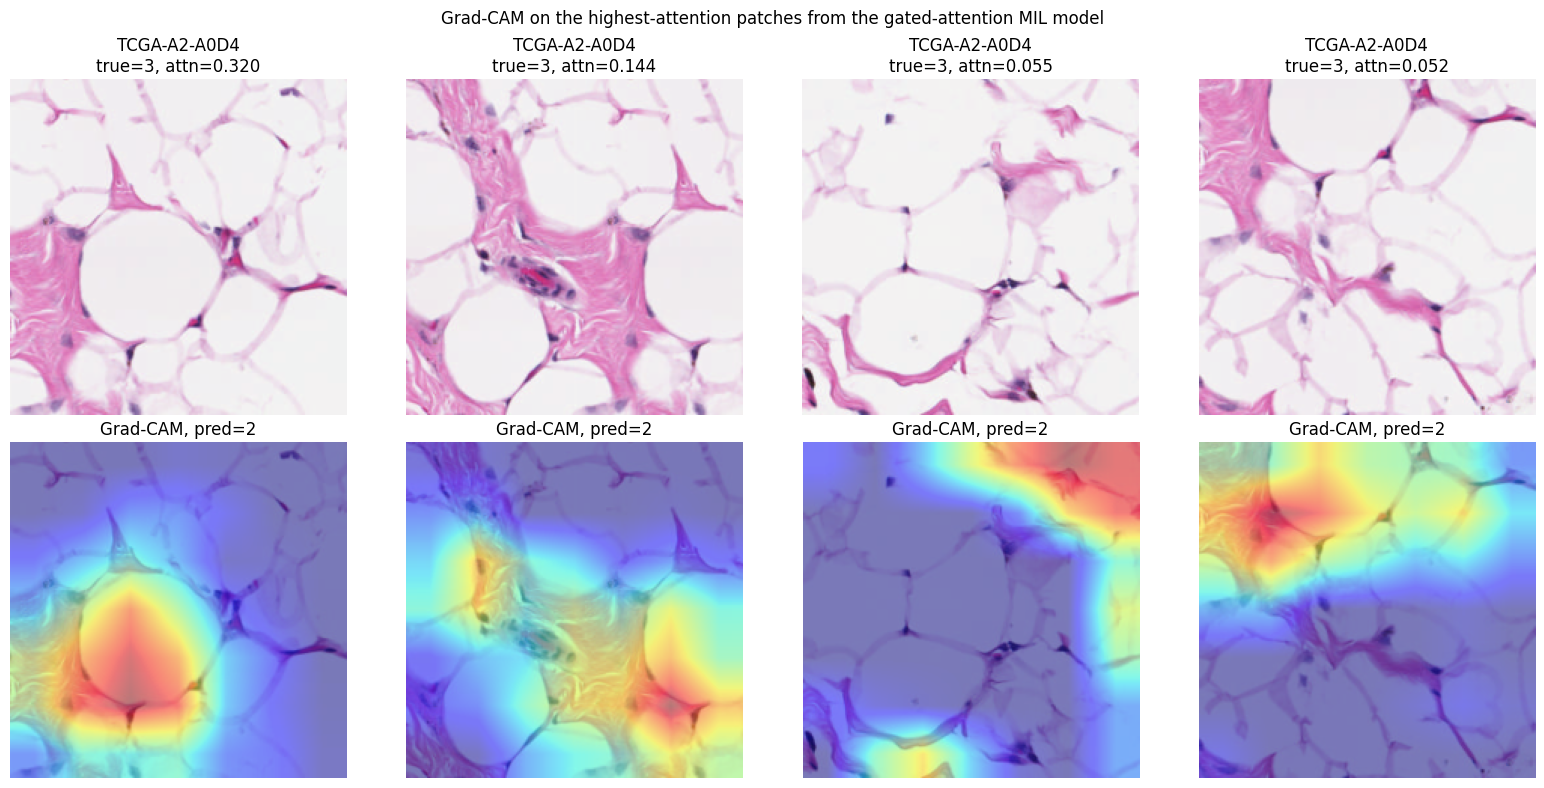

In [ ]:
class MILWithFrozenBackbone(nn.Module):
    '''Wraps the frozen backbone + a trained head into one forward pass, purely so Grad-CAM has
    a live computation graph to hook into. Not used during training -- only for this
    visualization, where running the backbone once per example patient is cheap.'''
    def __init__(self, backbone, head):
        super().__init__()
        self.backbone = backbone
        self.head = head

    def forward(self, bag):
        h = self.backbone(bag)
        logits, attn = self.head(h)
        return logits, attn, h


class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate_for_bag(self, bag, class_idx=None):
        self.model.eval()
        bag = bag.clone().requires_grad_(True)
        logits, attn_weights, _ = self.model(bag)
        if class_idx is None:
            class_idx = logits.argmax(dim=1).item()
        self.model.zero_grad()
        logits[0, class_idx].backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cams = (weights * self.activations).sum(dim=1, keepdim=True)
        cams = F.relu(cams)
        cams = F.interpolate(cams, size=(224, 224), mode="bilinear", align_corners=False)
        cams = cams.squeeze(1).cpu().numpy()
        cams = np.stack([(c - c.min()) / (c.max() - c.min() + 1e-8) for c in cams])
        return cams, class_idx, attn_weights.detach().cpu().numpy()


gradcam_model = MILWithFrozenBackbone(frozen_backbone, mil_head_for_gradcam).to(device)
gradcam = GradCAM(gradcam_model, gradcam_model.backbone.layer4[-1])

example_pid = gradcam_test_pids[0]
example_patches = load_patient_patches(example_pid, PATCH_CACHE_DIR)
example_bag = torch.stack([eval_transform(p) for p in example_patches]).to(device)
example_label = patient_label_map[example_pid]

cams, pred_class, attn_weights = gradcam.generate_for_bag(example_bag)
top_patch_idx = np.argsort(attn_weights)[-4:][::-1]  # 4 patches the model attended to most

fig, axes = plt.subplots(2, len(top_patch_idx), figsize=(4 * len(top_patch_idx), 8))
for col, patch_idx in enumerate(top_patch_idx):
    img = example_bag[patch_idx].detach().cpu().numpy().transpose(1, 2, 0)
    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img = np.clip(img, 0, 1)

    axes[0, col].imshow(img)
    axes[0, col].set_title(f"{example_pid}\ntrue={example_label}, attn={attn_weights[patch_idx]:.3f}")
    axes[0, col].axis("off")

    axes[1, col].imshow(img)
    axes[1, col].imshow(cams[patch_idx], cmap="jet", alpha=0.5)
    axes[1, col].set_title(f"Grad-CAM, pred={pred_class}")
    axes[1, col].axis("off")

plt.suptitle("Grad-CAM on the highest-attention patches from the gated-attention MIL model")
plt.tight_layout()
plt.show()

**Save Model**

In [ ]:
import torch, json

MODEL_SAVE_DIR = os.path.join(SAVE_DIR, "trained_mil_model")
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

# Save the best fold's head weights
torch.save(mil_fold_heads[-1].state_dict(), os.path.join(MODEL_SAVE_DIR, "mil_head.pt"))

# Save class names so a fresh session doesn't need to recompute them
with open(os.path.join(MODEL_SAVE_DIR, "class_names.json"), "w") as f:
    json.dump(list(class_names), f)

print(f"Model saved to {MODEL_SAVE_DIR}")

Model saved to /content/drive/MyDrive/tcga_brca_project/trained_mil_model


**Test Results**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import torch, torch.nn as nn, torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as T
import numpy as np
import json, os
import matplotlib.pyplot as plt

SAVE_DIR = "/content/drive/MyDrive/tcga_brca_project"
MODEL_SAVE_DIR = os.path.join(SAVE_DIR, "trained_mil_model")
device = "cuda" if torch.cuda.is_available() else "cpu"

with open(os.path.join(MODEL_SAVE_DIR, "class_names.json")) as f:
    class_names = json.load(f)

eval_transform = T.Compose([
    T.ToPILImage(), T.Resize((224, 224)), T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

frozen_backbone = models.resnet18(weights="IMAGENET1K_V1")
frozen_backbone.fc = nn.Identity()
frozen_backbone = frozen_backbone.to(device).eval()
for p in frozen_backbone.parameters():
    p.requires_grad = False


class GatedAttentionMILHead(nn.Module):
    def __init__(self, feat_dim=512, hidden_dim=128, n_classes=5, dropout=0.3):
        super().__init__()
        self.attn_V = nn.Sequential(nn.Linear(feat_dim, hidden_dim), nn.Tanh())
        self.attn_U = nn.Sequential(nn.Linear(feat_dim, hidden_dim), nn.Sigmoid())
        self.attn_w = nn.Linear(hidden_dim, 1)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(feat_dim, n_classes)

    def forward(self, h):
        a = self.attn_w(self.attn_V(h) * self.attn_U(h))
        a = torch.softmax(a, dim=0)
        bag_repr = self.dropout((a * h).sum(dim=0, keepdim=True))
        logits = self.classifier(bag_repr)
        return logits, a.squeeze(-1)


mil_head = GatedAttentionMILHead(n_classes=len(class_names)).to(device)
mil_head.load_state_dict(torch.load(os.path.join(MODEL_SAVE_DIR, "mil_head.pt"), map_location=device))
mil_head.eval()


class MILWithFrozenBackbone(nn.Module):
    def __init__(self, backbone, head):
        super().__init__()
        self.backbone = backbone
        self.head = head

    def forward(self, bag):
        h = self.backbone(bag)
        logits, attn = self.head(h)
        return logits, attn, h


class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate_for_bag(self, bag, class_idx=None):
        self.model.eval()
        bag = bag.clone().requires_grad_(True)
        logits, attn_weights, _ = self.model(bag)
        if class_idx is None:
            class_idx = logits.argmax(dim=1).item()
        self.model.zero_grad()
        logits[0, class_idx].backward()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cams = (weights * self.activations).sum(dim=1, keepdim=True)
        cams = F.relu(cams)
        cams = F.interpolate(cams, size=(224, 224), mode="bilinear", align_corners=False)
        cams = cams.squeeze(1).cpu().numpy()
        cams = np.stack([(c - c.min()) / (c.max() - c.min() + 1e-8) for c in cams])
        return cams, class_idx, attn_weights.detach().cpu().numpy()


test_model = MILWithFrozenBackbone(frozen_backbone, mil_head).to(device)
gradcam = GradCAM(test_model, test_model.backbone.layer4[-1])
print("Model loaded and ready for testing.")

Model loaded and ready for testing.


Upload one image file (a tissue patch, .png/.jpg/.tif) to test:


Saving Screenshot 2026-09-13 204801.png to Screenshot 2026-09-13 204801 (1).png

Predicted class: Basal
  Basal: 0.955
  Her2: 0.000
  LumA: 0.039
  LumB: 0.002
  Normal: 0.002


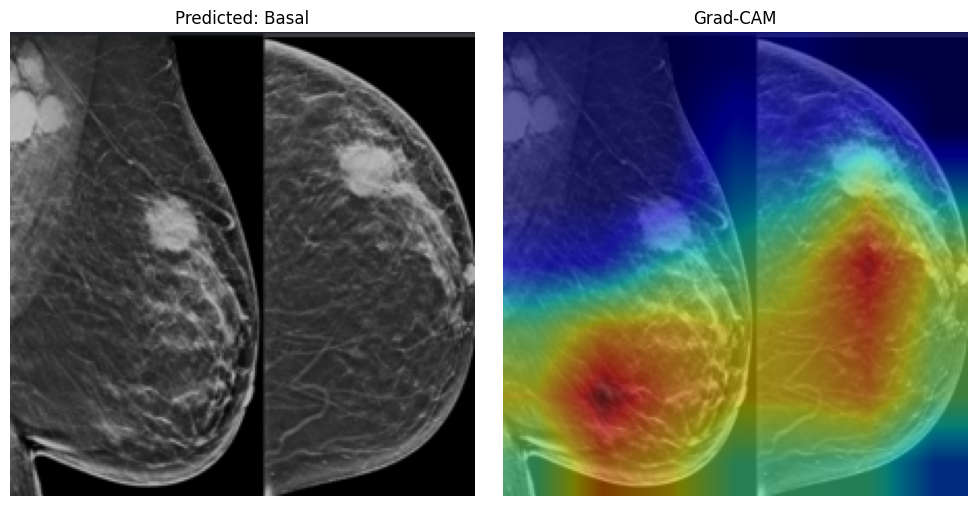

In [ ]:
from google.colab import files
from PIL import Image

print("Upload one image file (a tissue patch, .png/.jpg/.tif) to test:")
uploaded = files.upload()
test_image_path = list(uploaded.keys())[0]

img = Image.open(test_image_path).convert("RGB")
img_np = np.array(img)
test_tensor = eval_transform(img_np).unsqueeze(0).to(device)

with torch.no_grad():
    logits, attn, _ = test_model(test_tensor)
    probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
    pred_class_idx = int(np.argmax(probs))

print(f"\nPredicted class: {class_names[pred_class_idx]}")
for name, p in zip(class_names, probs):
    print(f"  {name}: {p:.3f}")

cams, pred_class, _ = gradcam.generate_for_bag(test_tensor)
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
display_img = test_tensor[0].detach().cpu().numpy().transpose(1, 2, 0)
display_img = display_img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
display_img = np.clip(display_img, 0, 1)
axes[0].imshow(display_img); axes[0].set_title(f"Predicted: {class_names[pred_class_idx]}"); axes[0].axis("off")
axes[1].imshow(display_img); axes[1].imshow(cams[0], cmap="jet", alpha=0.5); axes[1].set_title("Grad-CAM"); axes[1].axis("off")
plt.tight_layout()
plt.show()